# Loading libraries

In [1]:
# Load libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

I0000 00:00:1778504047.182016   34145 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778504047.218336   34145 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1778504048.046807   34145 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Checkpoint utilities

All trained models are saved under `models/<task>/<ticker>_<variant>.keras` (e.g. `models/task1.1/AAPL_lstm.keras`, `models/task1.2/MSFT_k3.keras`). `train_with_checkpoint` wraps `model.fit` with a `ModelCheckpoint` callback that keeps the **best** epoch by `val_loss` — re-running a cell overwrites the file with a fresh best.

In [2]:
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)


def checkpoint_path(task: str, name: str) -> Path:
    """Return models/<task>/<name>.keras and make sure the parent dir exists."""
    p = MODELS_DIR / task / f'{name}.keras'
    p.parent.mkdir(parents=True, exist_ok=True)
    return p


def train_with_checkpoint(model, train, val, save_path,
                          epochs=10, batch_size=64, verbose=1):
    """Fit `model` with a ModelCheckpoint callback that saves the best epoch."""
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    ckpt = ModelCheckpoint(
        filepath=str(save_path),
        monitor='val_loss',
        save_best_only=True,
        verbose=0,
    )
    history = model.fit(
        train.X, train.y,
        validation_data=(val.X, val.y),
        epochs=epochs, batch_size=batch_size,
        callbacks=[ckpt],
        verbose=verbose,
    )
    print(f"  ↳ best checkpoint → {save_path}")
    return history


print(f"Checkpoints will be saved under: {MODELS_DIR.resolve()}")

Checkpoints will be saved under: /home/anchin/Projects/Time-series-data-and-application-to-stock-markets/models


# TASK 1


# 1.1 Multiple-feature extension


In [3]:
# Load AAPL data
AAPL = pd.read_csv('Nasdaq data/csv/AAPL.csv')

In [4]:
# Load MSFT data
MSFT = pd.read_csv('Nasdaq data/csv/MSFT.csv')

In [5]:
# Load NVDA data
NVDA = pd.read_csv('Nasdaq data/csv/NVDA.csv')

In [6]:
# Show some first data samples for AAPL
AAPL.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [7]:
# Get some info about the AAPL data
display(AAPL.info())
print("="*75)
# Get some info about the MSFT data
MSFT.info()
print("="*75)
# Get some info about the NVDA data
NVDA.info()

<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  str    
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 682.7 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 9264 entries, 0 to 9263
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            9264 non-null   str    
 1   Low             9264 non-null   float64
 2   Open            9264 non-null   float64
 3   Volume          9264 non-null   int64  
 4   High            9264 non-null   float64
 5   Close           9264 non-null   float64
 6   Adjusted Close  9264 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 597.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 6013 entries, 0 to 6012
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            6013 non-null   str    
 1   Low             6013 non-null   float64
 2   Open            6013 non-null   float64
 3   Volume          6013 non-null   int64  
 4   High            6013 non-null   float64
 5   Close           6013 non-

### Data pipeline

**Features added** (none of these are in the raw CSVs):

| Feature | Formula | Meaning |
|---|---|---|
| `daily_return` | `Close.pct_change()` | Day-over-day % change |
| `MA5`, `MA20` | rolling mean of `Close`, 5 / 20 days | Short / medium-term trend |
| `RSI` (14) | `100 − 100 / (1 + avg_gain / avg_loss)` over 14 days | Momentum, range [0, 100]. >70 overbought, <30 oversold |
| `MACD` | `EMA12(Close) − EMA26(Close)` | Trend-following momentum |
| `MACD_signal` | `EMA9(MACD)` | Smoothed MACD; crossovers signal trend changes |
| `volatility` | rolling std of `daily_return`, 20 days | Risk / price stability |

All indicators are **causal** (only look backward), so computing them on the full series before splitting introduces no future leakage.


In [8]:
# Technical indicators — all causal (look only at past values)
def add_technical_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(out['Date']):
        out['Date'] = pd.to_datetime(out['Date'], format='%d-%m-%Y')
    out = out.sort_values('Date').reset_index(drop=True)

    out['daily_return'] = out['Close'].pct_change()
    out['MA5']  = out['Close'].rolling(5).mean()
    out['MA20'] = out['Close'].rolling(20).mean()

    delta = out['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-8)
    out['RSI'] = 100 - 100 / (1 + rs)

    ema12 = out['Close'].ewm(span=12, adjust=False).mean()
    ema26 = out['Close'].ewm(span=26, adjust=False).mean()
    out['MACD']        = ema12 - ema26
    out['MACD_signal'] = out['MACD'].ewm(span=9, adjust=False).mean()

    out['volatility'] = out['daily_return'].rolling(20).std()
    return out


**Pipeline:** add features → build sliding windows → chronological split (70 / 15 / 15) → **per-window MinMax** normalisation (matches the sample-code style: each window is normalised by its own min / max).

- **Input** — every feature in `FEATURE_COLS` (OHLCV, Adjusted Close, and the 7 engineered indicators) — shape `(N, window_size, n_features)`.
- **Label** — `Adjusted Close` `horizon` days after the window. Splits are **dividend / split adjusted**, which matters on AAPL's 30+ year history.
- **Per-window MinMax** — for each window, every feature is normalised independently by its own min / max over the 30 timesteps. The label uses the *Adjusted Close column's* window min / max (so we can denormalise predictions back to dollars).

Returns three `Split` namedtuples (`train`, `val`, `test`), each with `.X`, `.y`, `.label_min`, `.label_max`. Use `denormalize_label(...)` on predictions to recover real prices.


In [9]:
from typing import NamedTuple
from sklearn.model_selection import train_test_split

FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close',
                'daily_return', 'MA5', 'MA20', 'RSI',
                'MACD', 'MACD_signal', 'volatility']
LABEL_COL = 'Adjusted Close'


class Split(NamedTuple):
    X:         np.ndarray  # (N, window_size, n_features), float32, in [0, 1]
    y:         np.ndarray  # (N,)                          float32, in [0, 1]
    label_min: np.ndarray  # (N,)  per-window Adj Close min — for denormalisation
    label_max: np.ndarray  # (N,)  per-window Adj Close max


def build_pipeline(df, name, window_size=30, horizon=1,
                   val_ratio=0.15, test_ratio=0.15, verbose=True):
    """Add features → window → chronological split → per-window MinMax."""
    feat = add_technical_features(df).dropna().reset_index(drop=True)
    label_idx = FEATURE_COLS.index(LABEL_COL)

    arr   = feat[FEATURE_COLS].values.astype(np.float32)
    label = feat[LABEL_COL].values.astype(np.float32)

    # Sliding windows: X = (window_size, n_features), y = Adj Close at t + horizon
    X_list, y_list = [], []
    for i in range(len(arr) - window_size - horizon + 1):
        X_list.append(arr[i : i + window_size])
        y_list.append(label[i + window_size + horizon - 1])
    X = np.stack(X_list)
    y = np.array(y_list, dtype=np.float32)

    # Chronological split (shuffle=False) — same pattern as the sample notebook
    X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
    val_size_adj = val_ratio / (1 - test_ratio)
    X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=val_size_adj, shuffle=False)

    def normalise(Xs, ys):
        # Per-window, per-feature MinMax (axis=1 → time axis only)
        fmins = Xs.min(axis=1, keepdims=True)              # (N, 1, F)
        fmaxs = Xs.max(axis=1, keepdims=True)
        Xn = (Xs - fmins) / (fmaxs - fmins + 1e-8)
        # Label uses the Adjusted Close column's per-window stats so it can be denormalised
        lmin = fmins[:, 0, label_idx]                      # (N,)
        lmax = fmaxs[:, 0, label_idx]
        yn = (ys - lmin) / (lmax - lmin + 1e-8)
        return Split(Xn.astype(np.float32), yn.astype(np.float32), lmin, lmax)

    train, val, test = normalise(X_train, y_train), normalise(X_val, y_val), normalise(X_test, y_test)

    if verbose:
        print(f"[{name:5s}]  X_train: {train.X.shape}  X_val: {val.X.shape}  "
              f"X_test: {test.X.shape}  (window={window_size}, horizon={horizon}, "
              f"n_features={train.X.shape[-1]})")

    return train, val, test


def denormalize_label(y_norm, label_min, label_max):
    """Invert per-window MinMax for predictions:
        y_pred_real = denormalize_label(model.predict(test.X).ravel(),
                                        test.label_min, test.label_max)
    """
    return y_norm * (label_max - label_min + 1e-8) + label_min


In [10]:
# Run pipeline for each ticker → produces <name>_train / _val / _test (each is a Split namedtuple)
AAPL_train, AAPL_val, AAPL_test = build_pipeline(AAPL, 'AAPL')
MSFT_train, MSFT_val, MSFT_test = build_pipeline(MSFT, 'MSFT')
NVDA_train, NVDA_val, NVDA_test = build_pipeline(NVDA, 'NVDA')


[AAPL ]  X_train: (7378, 30, 13)  X_val: (1581, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=1, n_features=13)


[MSFT ]  X_train: (6449, 30, 13)  X_val: (1382, 30, 13)  X_test: (1383, 30, 13)  (window=30, horizon=1, n_features=13)
[NVDA ]  X_train: (4173, 30, 13)  X_val: (895, 30, 13)  X_test: (895, 30, 13)  (window=30, horizon=1, n_features=13)


### AAPL train / validation / test split visualization

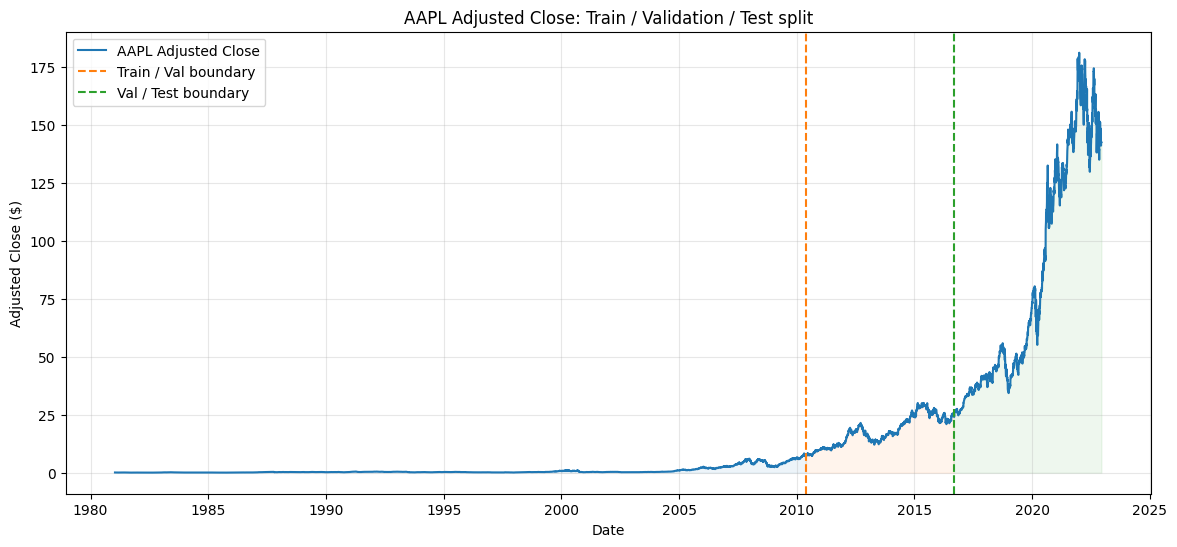

In [11]:
# Plot the AAPL adjusted close trend with chronological split boundaries from the pipeline.
window_size = 30
feat = add_technical_features(AAPL).dropna().reset_index(drop=True)
feat['Date'] = pd.to_datetime(feat['Date'], errors='coerce')
feat = feat.sort_values('Date').reset_index(drop=True)

train_end = AAPL_train.X.shape[0] + window_size - 1
val_end = train_end + AAPL_val.X.shape[0]

plt.figure(figsize=(14, 6))
plt.plot(feat['Date'], feat['Adjusted Close'], label='AAPL Adjusted Close', color='tab:blue')
plt.axvline(feat.loc[train_end, 'Date'], color='tab:orange', linestyle='--', label='Train / Val boundary')
plt.axvline(feat.loc[val_end, 'Date'], color='tab:green', linestyle='--', label='Val / Test boundary')
plt.fill_between(feat['Date'][:train_end+1], feat['Adjusted Close'][:train_end+1], color='tab:blue', alpha=0.08)
plt.fill_between(feat['Date'][train_end+1:val_end+1], feat['Adjusted Close'][train_end+1:val_end+1], color='tab:orange', alpha=0.08)
plt.fill_between(feat['Date'][val_end+1:], feat['Adjusted Close'][val_end+1:], color='tab:green', alpha=0.08)
plt.title('AAPL Adjusted Close: Train / Validation / Test split')
plt.xlabel('Date')
plt.ylabel('Adjusted Close ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
# Sanity checks: shapes, normalisation range, label denormalisation
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Label: {LABEL_COL!r}\n")

for name, tr, va, te in [('AAPL', AAPL_train, AAPL_val, AAPL_test),
                         ('MSFT', MSFT_train, MSFT_val, MSFT_test),
                         ('NVDA', NVDA_train, NVDA_val, NVDA_test)]:
    print(f"[{name}]  X_train {tr.X.shape}  y_train {tr.y.shape}  "
          f"|  X_val {va.X.shape}  |  X_test {te.X.shape}")
    print(f"        X (must be [0, 1]): [{tr.X.min():.3f}, {tr.X.max():.3f}]   "
          f"y (can exceed [0, 1] when day t+1 breaks the window's range): "
          f"[{tr.y.min():.3f}, {tr.y.max():.3f}]")

# Round-trip check: denormalise the first 3 test labels back to dollars
y_recovered = denormalize_label(AAPL_test.y[:3], AAPL_test.label_min[:3], AAPL_test.label_max[:3])
print(f"\nAAPL test labels denormalised → {y_recovered.round(3).tolist()}  (real Adjusted Close prices)")


Features (13): ['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close', 'daily_return', 'MA5', 'MA20', 'RSI', 'MACD', 'MACD_signal', 'volatility']
Label: 'Adjusted Close'

[AAPL]  X_train (7378, 30, 13)  y_train (7378,)  |  X_val (1581, 30, 13)  |  X_test (1581, 30, 13)
        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-1.599, 2.000]
[MSFT]  X_train (6449, 30, 13)  y_train (6449,)  |  X_val (1382, 30, 13)  |  X_test (1383, 30, 13)
        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-2.562, 1.984]
[NVDA]  X_train (4173, 30, 13)  y_train (4173,)  |  X_val (895, 30, 13)  |  X_test (895, 30, 13)


        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-0.812, 2.489]

AAPL test labels denormalised → [24.843000411987305, 25.076000213623047, 25.069000244140625]  (real Adjusted Close prices)


In [13]:
# Train AAPL LSTM (LSTM replaces the sample's Conv1D per the project spec; same MSE/Adam pattern)
# Best epoch (by val_loss) is checkpointed to models/task1.1/AAPL_lstm.keras
AAPL_LSTM_model = Sequential([
    Input(shape=AAPL_train.X.shape[1:]),    # (window_size, n_features) = (30, 13)
    LSTM(64),
    Dense(1),
])
AAPL_LSTM_model.compile(optimizer='adam', loss='mse', metrics=['mse'])

history = train_with_checkpoint(
    AAPL_LSTM_model, AAPL_train, AAPL_val,
    save_path=checkpoint_path('task1.1', 'AAPL_lstm'),
    epochs=10, batch_size=64, verbose=1,
)
# Reload the best-by-val-loss weights so downstream cells use the checkpointed model
AAPL_LSTM_model = load_model(checkpoint_path('task1.1', 'AAPL_lstm'))

Epoch 1/10


W0000 00:00:1778504049.157252   34145 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


  1/116 ━━━━━━━━━━━━━━━━━━━━ 1:32 808ms/step - loss: 0.2006 - mse: 0.2006

  5/116 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1731 - mse: 0.1731   

 10/116 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1548 - mse: 0.1548

...

105/116 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0280 - mse: 0.0280

109/116 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0279 - mse: 0.0279

114/116 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0279 - mse: 0.0279

116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0266 - mse: 0.0266 - val_loss: 0.0254 - val_mse: 0.0254


  ↳ best checkpoint → models/task1.1/AAPL_lstm.keras


### Training curves


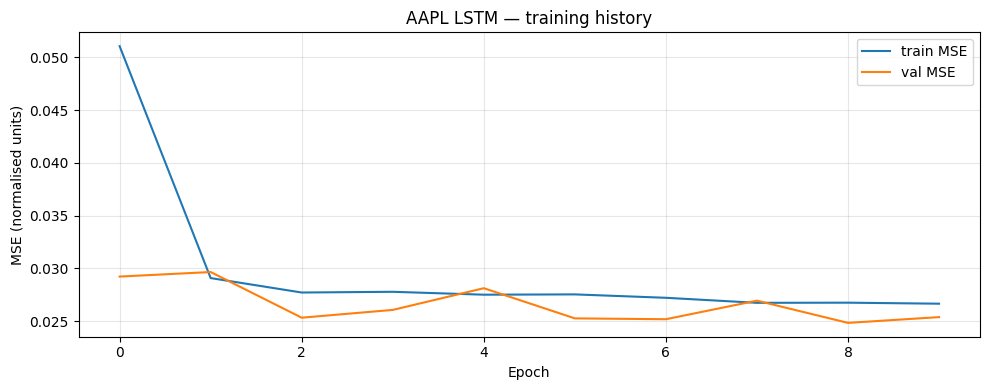

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='train MSE', color='tab:blue')
plt.plot(history.history['val_loss'], label='val MSE',   color='tab:orange')
plt.title('AAPL LSTM — training history')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalised units)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Test set evaluation — denormalise back to dollar units


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test, then invert per-window MinMax → real Adjusted Close in dollars
y_pred_norm = AAPL_LSTM_model.predict(AAPL_test.X, verbose=0).ravel()
y_pred = denormalize_label(y_pred_norm, AAPL_test.label_min, AAPL_test.label_max)
y_real = denormalize_label(AAPL_test.y,  AAPL_test.label_min, AAPL_test.label_max)

mse_norm = mean_squared_error(AAPL_test.y, y_pred_norm)
mse_dol  = mean_squared_error(y_real, y_pred)
rmse_dol = np.sqrt(mse_dol)
mae_dol  = mean_absolute_error(y_real, y_pred)

print(f"AAPL test set  ({len(y_pred)} samples):")
print(f"  MSE  (normalised)  : {mse_norm:.5f}   ← compare with sample's 0.033")
print(f"  MSE  ($²)          : {mse_dol:.4f}")
print(f"  RMSE ($)           : {rmse_dol:.4f}")
print(f"  MAE  ($)           : {mae_dol:.4f}")


AAPL test set  (1581 samples):
  MSE  (normalised)  : 0.02466   ← compare with sample's 0.033
  MSE  ($²)          : 4.0297
  RMSE ($)           : 2.0074
  MAE  ($)           : 1.2414


### Predicted vs real Adjusted Close (AAPL test set)


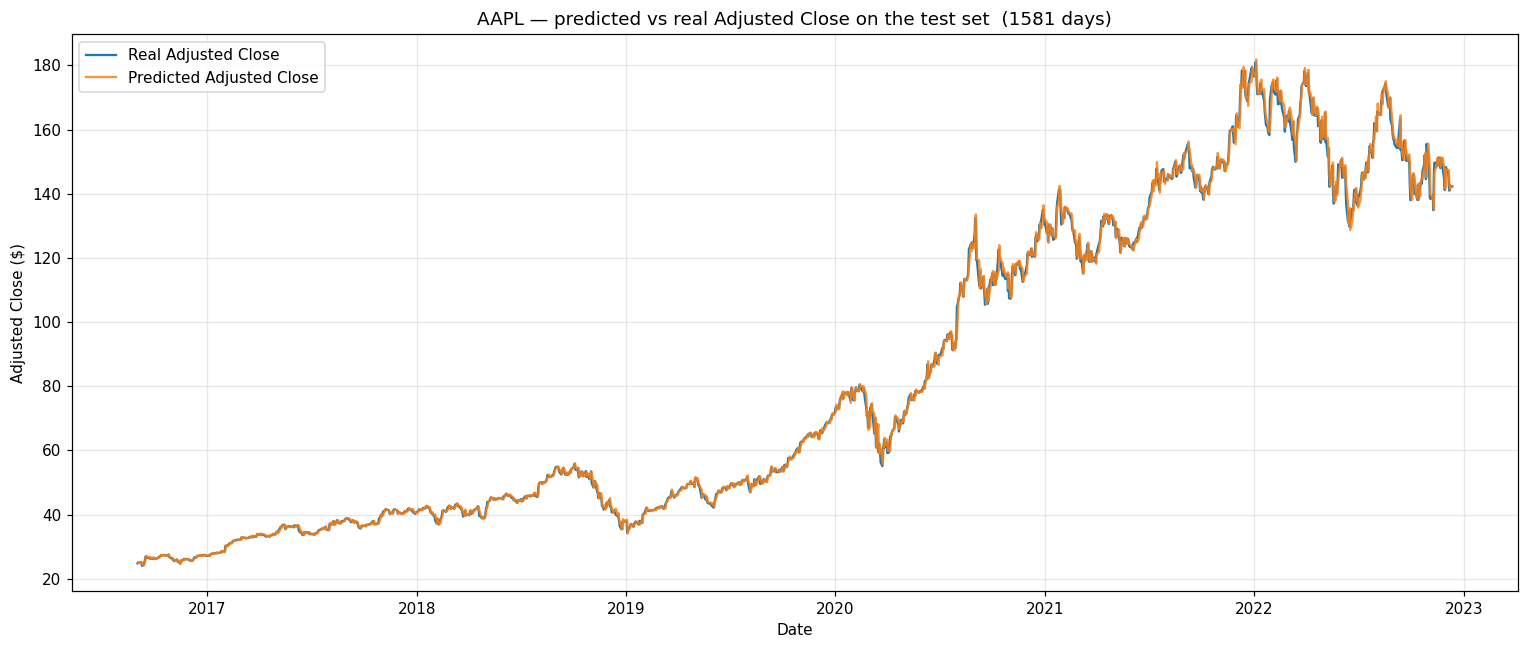

In [16]:
# Recover the calendar date for each test label so x-axis is real time, not row index
window_size, horizon = 30, 1
feat_aapl = add_technical_features(AAPL).dropna().reset_index(drop=True)
test_start_idx = AAPL_train.X.shape[0] + AAPL_val.X.shape[0]
test_label_dates = feat_aapl['Date'].iloc[
    test_start_idx + window_size + horizon - 1 :
    test_start_idx + window_size + horizon - 1 + len(y_pred)
].reset_index(drop=True)

plt.figure(figsize=(14, 6), dpi=110)
plt.plot(test_label_dates, y_real, label='Real Adjusted Close',     color='tab:blue')
plt.plot(test_label_dates, y_pred, label='Predicted Adjusted Close', color='tab:orange', alpha=0.85)
plt.title(f'AAPL — predicted vs real Adjusted Close on the test set  ({len(y_pred)} days)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 1.1 extension — apply the same pipeline to MSFT and NVDA

The pipeline is ticker-agnostic. We reuse the splits already built by `build_pipeline` (`MSFT_train/_val/_test`, `NVDA_train/_val/_test`) and train an LSTM with **identical architecture and hyperparameters** as the AAPL baseline. Each model's best epoch (by `val_loss`) is checkpointed to `models/task1.1/<TICKER>_lstm.keras` and reloaded so downstream evaluation uses the best weights.

`evaluate_test` is defined here (rather than later in 1.2) because we need it to score all three tickers in one comparison table — 1.2 will then reuse it as-is.

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


def build_lstm(input_shape):
    """LSTM(64) → Dense(1), Adam + MSE — the architecture used everywhere in Task 1."""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64),
        Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    return model


def evaluate_test(model, test):
    """Predict on the test split, denormalise, and return (y_real, y_pred, metrics-dict)."""
    y_pred_norm = model.predict(test.X, verbose=0).ravel()
    y_pred = denormalize_label(y_pred_norm, test.label_min, test.label_max)
    y_real = denormalize_label(test.y,      test.label_min, test.label_max)
    mse_norm = mean_squared_error(test.y, y_pred_norm)
    mse_dol  = mean_squared_error(y_real, y_pred)
    return y_real, y_pred, {
        'MSE (norm)': mse_norm,
        'MSE ($²)':   mse_dol,
        'RMSE ($)':   np.sqrt(mse_dol),
        'MAE ($)':    mean_absolute_error(y_real, y_pred),
    }


TICKERS = ['AAPL', 'MSFT', 'NVDA']
SPLITS_K1 = {
    'AAPL': (AAPL_train, AAPL_val, AAPL_test),
    'MSFT': (MSFT_train, MSFT_val, MSFT_test),
    'NVDA': (NVDA_train, NVDA_val, NVDA_test),
}

# results_k1[ticker] = {'model','history','train','val','test'}
results_k1 = {
    'AAPL': {'model': AAPL_LSTM_model, 'history': history,
             'train': AAPL_train, 'val': AAPL_val, 'test': AAPL_test},
}

for ticker in ['MSFT', 'NVDA']:
    tr, va, te = SPLITS_K1[ticker]
    print(f"\n=== Training {ticker} LSTM (k=1) ===")
    model = build_lstm(tr.X.shape[1:])
    hist  = train_with_checkpoint(
        model, tr, va,
        save_path=checkpoint_path('task1.1', f'{ticker}_lstm'),
        epochs=10, batch_size=64, verbose=1,
    )
    # Reload best-by-val-loss checkpoint
    model = load_model(checkpoint_path('task1.1', f'{ticker}_lstm'))
    results_k1[ticker] = {'model': model, 'history': hist,
                          'train': tr, 'val': va, 'test': te}

# Expose MSFT/NVDA models under conventional names too, for symmetry with AAPL_LSTM_model
MSFT_LSTM_model = results_k1['MSFT']['model']
NVDA_LSTM_model = results_k1['NVDA']['model']


=== Training MSFT LSTM (k=1) ===
Epoch 1/10


  1/101 ━━━━━━━━━━━━━━━━━━━━ 1:10 704ms/step - loss: 0.7931 - mse: 0.7931

  7/101 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5292 - mse: 0.5292   

 12/101 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4305 - mse: 0.4305

 17/101 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3739 - mse: 0.3739

...

55/66 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0287 - mse: 0.0287

59/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0286 - mse: 0.0286

63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0286 - mse: 0.0286

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0277 - mse: 0.0277 - val_loss: 0.0390 - val_mse: 0.0390


  ↳ best checkpoint → models/task1.1/NVDA_lstm.keras


#### Cross-ticker comparison (k = 1)

Per-ticker dollar metrics are not directly comparable (NVDA spans a tighter dollar range than AAPL), but the **normalised MSE** is — it's already on the per-window-MinMax scale.

In [18]:
print(f"Task 1.1 — k=1 forecast, all tickers\n")
print(f"{'ticker':>6}  {'MSE (norm)':>11}  {'MSE ($²)':>10}  {'RMSE ($)':>10}  {'MAE ($)':>10}")
print('-' * 55)
for ticker in TICKERS:
    r = results_k1[ticker]
    _, _, m = evaluate_test(r['model'], r['test'])
    print(f"{ticker:>6}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>10.4f}  "
          f"{m['RMSE ($)']:>10.4f}  {m['MAE ($)']:>10.4f}")

Task 1.1 — k=1 forecast, all tickers

ticker   MSE (norm)    MSE ($²)    RMSE ($)     MAE ($)
-------------------------------------------------------


  AAPL      0.02466      4.0297      2.0074      1.2414


  MSFT      0.02919     13.8691      3.7241      2.4457


  NVDA      0.02588     31.9579      5.6531      3.7033


# 1.2 kᵗʰ day forecast

Task 1.1 predicts the **next** day (`horizon = 1`). Task 1.2 instead predicts the price on the **kᵗʰ day after the input window** — e.g., the 3rd or 7th day ahead.

The `build_pipeline(..., horizon=k)` helper from 1.1 already supports this: each label is `label[i + window_size + k - 1]`, i.e., the kᵗʰ day after the window ends. So 1.2 reuses the same pipeline, model, and training loop — only `horizon` changes.

We train an LSTM at **k ∈ {3, 7}** for all three tickers (AAPL, MSFT, NVDA), identical architecture and hyperparameters as 1.1, and compare against the k = 1 baseline. Best epochs are checkpointed to `models/task1.2/<TICKER>_k<k>.keras`. As expected, forecast error grows with k — the further ahead we predict, the less the recent 30-day window carries information about the target day.

In [19]:
# Build pipelines and train LSTMs for each (ticker, k) — same architecture & hyperparameters as 1.1
# build_lstm was defined in 1.1's extension cell.
K_VALUES = [3, 7]
RAW_FRAMES = {'AAPL': AAPL, 'MSFT': MSFT, 'NVDA': NVDA}

# results_kth[(ticker, k)] = dict(model, history, train, val, test)
results_kth = {}

for ticker in TICKERS:
    for k in K_VALUES:
        print(f"\n=== Training {ticker} LSTM (k={k}) ===")
        tr, va, te = build_pipeline(RAW_FRAMES[ticker], f'{ticker} k={k}', horizon=k)
        model = build_lstm(tr.X.shape[1:])
        hist  = train_with_checkpoint(
            model, tr, va,
            save_path=checkpoint_path('task1.2', f'{ticker}_k{k}'),
            epochs=10, batch_size=64, verbose=0,
        )
        model = load_model(checkpoint_path('task1.2', f'{ticker}_k{k}'))
        results_kth[(ticker, k)] = {'model': model, 'history': hist,
                                    'train': tr, 'val': va, 'test': te}
        print(f"  → final val_loss = {hist.history['val_loss'][-1]:.5f}  "
              f"(best = {min(hist.history['val_loss']):.5f})")


=== Training AAPL LSTM (k=3) ===
[AAPL k=3]  X_train: (7376, 30, 13)  X_val: (1581, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=3, n_features=13)


  ↳ best checkpoint → models/task1.2/AAPL_k3.keras
  → final val_loss = 0.08036  (best = 0.07842)

=== Training AAPL LSTM (k=7) ===
[AAPL k=7]  X_train: (7373, 30, 13)  X_val: (1580, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=7, n_features=13)


  ↳ best checkpoint → models/task1.2/AAPL_k7.keras
  → final val_loss = 0.20052  (best = 0.18749)

=== Training MSFT LSTM (k=3) ===
[MSFT k=3]  X_train: (6448, 30, 13)  X_val: (1382, 30, 13)  X_test: (1382, 30, 13)  (window=30, horizon=3, n_features=13)


  ↳ best checkpoint → models/task1.2/MSFT_k3.keras
  → final val_loss = 0.10961  (best = 0.10744)

=== Training MSFT LSTM (k=7) ===
[MSFT k=7]  X_train: (6444, 30, 13)  X_val: (1382, 30, 13)  X_test: (1382, 30, 13)  (window=30, horizon=7, n_features=13)


  ↳ best checkpoint → models/task1.2/MSFT_k7.keras
  → final val_loss = 0.24229  (best = 0.22466)

=== Training NVDA LSTM (k=3) ===
[NVDA k=3]  X_train: (4171, 30, 13)  X_val: (895, 30, 13)  X_test: (895, 30, 13)  (window=30, horizon=3, n_features=13)


  ↳ best checkpoint → models/task1.2/NVDA_k3.keras
  → final val_loss = 0.11879  (best = 0.11650)

=== Training NVDA LSTM (k=7) ===
[NVDA k=7]  X_train: (4169, 30, 13)  X_val: (894, 30, 13)  X_test: (894, 30, 13)  (window=30, horizon=7, n_features=13)


  ↳ best checkpoint → models/task1.2/NVDA_k7.keras
  → final val_loss = 0.34567  (best = 0.32789)


### Test-set comparison: k ∈ {1, 3, 7} across all three tickers

All metrics are computed on the **denormalised** test predictions (real Adjusted Close dollars). Normalised MSE is on the per-window MinMax scale and is the most directly comparable across tickers; the dollar metrics aren't (NVDA's prices live in a different range than AAPL's).

In [20]:
# Build a single table covering all (ticker, k) combinations.
# evaluate_test was defined in the 1.1 extension cell.

print(f"Task 1.2 — kᵗʰ-day forecast, all tickers × k ∈ {{1, 3, 7}}\n")
print(f"{'ticker':>6}  {'k':>3}  {'MSE (norm)':>11}  {'MSE ($²)':>10}  {'RMSE ($)':>10}  {'MAE ($)':>10}")
print('-' * 62)

for ticker in TICKERS:
    # k = 1 baseline (from 1.1)
    r1 = results_k1[ticker]
    _, _, m = evaluate_test(r1['model'], r1['test'])
    print(f"{ticker:>6}  {1:>3}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>10.4f}  "
          f"{m['RMSE ($)']:>10.4f}  {m['MAE ($)']:>10.4f}")
    # k ∈ {3, 7} from 1.2
    for k in K_VALUES:
        r = results_kth[(ticker, k)]
        _, _, m = evaluate_test(r['model'], r['test'])
        print(f"{ticker:>6}  {k:>3}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>10.4f}  "
              f"{m['RMSE ($)']:>10.4f}  {m['MAE ($)']:>10.4f}")
    print('-' * 62)

Task 1.2 — kᵗʰ-day forecast, all tickers × k ∈ {1, 3, 7}

ticker    k   MSE (norm)    MSE ($²)    RMSE ($)     MAE ($)
--------------------------------------------------------------


  AAPL    1      0.02466      4.0297      2.0074      1.2414


  AAPL    3      0.07586     10.7813      3.2835      2.0828


  AAPL    7      0.18256     24.4697      4.9467      3.2532
--------------------------------------------------------------
  MSFT    1      0.02919     13.8691      3.7241      2.4457


  MSFT    3      0.07555     34.4678      5.8709      3.9180


  MSFT    7      0.16959     75.4102      8.6839      6.0115
--------------------------------------------------------------
  NVDA    1      0.02588     31.9579      5.6531      3.7033


  NVDA    3      0.07120     89.1958      9.4444      6.3229


  NVDA    7      0.17822    196.3049     14.0109      9.4944
--------------------------------------------------------------


### Predicted vs real — AAPL at k = 3 and k = 7

Visualised for AAPL only — the table above covers MSFT and NVDA in numbers, and a second visual demonstrates the same error-grows-with-k behaviour. The label for the iᵗʰ test window lands at original index `i + N_train + N_val + window_size + k − 1` in the feature-engineered series.

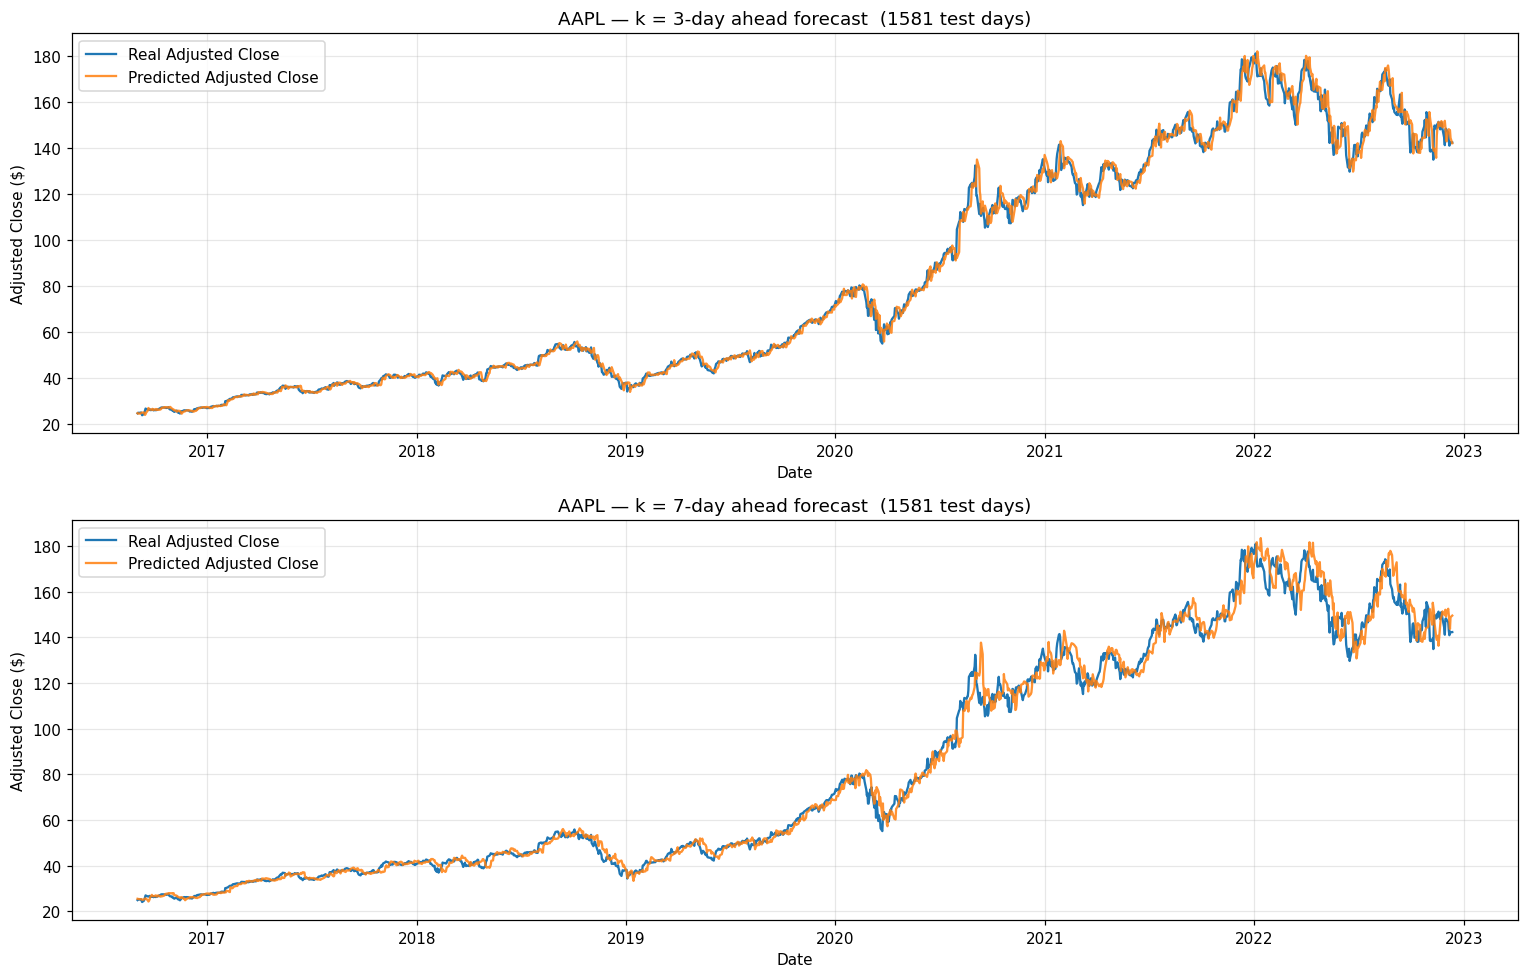

In [21]:
window_size = 30
fig, axes = plt.subplots(2, 1, figsize=(14, 9), dpi=110)

for ax, k in zip(axes, K_VALUES):
    r = results_kth[('AAPL', k)]
    y_real, y_pred, _ = evaluate_test(r['model'], r['test'])

    test_start_idx = r['train'].X.shape[0] + r['val'].X.shape[0]
    label_offset   = window_size + k - 1
    dates = feat_aapl['Date'].iloc[
        test_start_idx + label_offset :
        test_start_idx + label_offset + len(y_pred)
    ].reset_index(drop=True)

    ax.plot(dates, y_real, label='Real Adjusted Close',      color='tab:blue')
    ax.plot(dates, y_pred, label='Predicted Adjusted Close', color='tab:orange', alpha=0.85)
    ax.set_title(f'AAPL — k = {k}-day ahead forecast  ({len(y_pred)} test days)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Adjusted Close ($)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 1.3 k consecutive days forecast

Tasks 1.1–1.2 predict a **single** future day (next day, or the kᵗʰ day). Task 1.3 instead predicts the **entire sequence** of the next k days at once: for k = 3 the model outputs `[day+1, day+2, day+3]`; for k = 7 it outputs `[day+1, …, day+7]`.

The only structural changes vs 1.2:

- **Label** is now a length-k vector per window — `y[i] = label[i+window_size : i+window_size+k]`.
- **Model head** is `Dense(k)` instead of `Dense(1)`. Same LSTM(64) trunk, same Adam + MSE, same per-window MinMax (the input window's Adj Close min/max scales all k label components uniformly so denormalisation stays one-pair-per-window).
- **Metrics** are reported per step (`step=1` ≈ shortest horizon, `step=k` ≈ longest) so we can read the error-growth curve directly.

Checkpoints land under `models/task1.3/<TICKER>_k<k>.keras`. The window count per (ticker, k) matches 1.2 exactly, since both pipelines need k future days after the input window.

In [22]:
# Multi-step pipeline: same per-window MinMax as 1.1/1.2, but labels are k consecutive future Adj Close values.


class MultiStepSplit(NamedTuple):
    X:         np.ndarray  # (N, window_size, n_features)
    y:         np.ndarray  # (N, k)                       — normalised
    label_min: np.ndarray  # (N,)  per-window Adj Close min
    label_max: np.ndarray  # (N,)  per-window Adj Close max


def build_pipeline_multistep(df, name, k, window_size=30,
                             val_ratio=0.15, test_ratio=0.15, verbose=True):
    """Same pipeline as `build_pipeline`, but each label is the next k Adj Close values."""
    feat = add_technical_features(df).dropna().reset_index(drop=True)
    label_idx = FEATURE_COLS.index(LABEL_COL)

    arr   = feat[FEATURE_COLS].values.astype(np.float32)
    label = feat[LABEL_COL].values.astype(np.float32)

    X_list, y_list = [], []
    for i in range(len(arr) - window_size - k + 1):
        X_list.append(arr[i : i + window_size])
        y_list.append(label[i + window_size : i + window_size + k])
    X = np.stack(X_list)
    y = np.stack(y_list).astype(np.float32)               # (N, k)

    X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
    val_size_adj = val_ratio / (1 - test_ratio)
    X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=val_size_adj, shuffle=False)

    def normalise(Xs, ys):
        fmins = Xs.min(axis=1, keepdims=True)             # (N, 1, F)
        fmaxs = Xs.max(axis=1, keepdims=True)
        Xn    = (Xs - fmins) / (fmaxs - fmins + 1e-8)
        lmin  = fmins[:, 0, label_idx]                    # (N,)
        lmax  = fmaxs[:, 0, label_idx]
        # broadcast the input-window's stats across all k label steps
        yn    = (ys - lmin[:, None]) / (lmax - lmin + 1e-8)[:, None]
        return MultiStepSplit(Xn.astype(np.float32), yn.astype(np.float32), lmin, lmax)

    train, val, test = normalise(X_train, y_train), normalise(X_val, y_val), normalise(X_test, y_test)

    if verbose:
        print(f"[{name:9s}]  X_train: {train.X.shape}  y_train: {train.y.shape}  "
              f"X_test: {test.X.shape}  (window={window_size}, k={k})")
    return train, val, test


def build_lstm_multistep(input_shape, k):
    """LSTM(64) → Dense(k) — same trunk as build_lstm, vector head for k-day forecast."""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64),
        Dense(k),
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    return model


def denormalize_label_multistep(y_norm, label_min, label_max):
    """Invert per-window MinMax for (N, k) predictions."""
    return y_norm * (label_max - label_min + 1e-8)[:, None] + label_min[:, None]


def evaluate_test_multistep(model, test):
    """Predict → denormalise → return (y_real (N,k), y_pred (N,k), metrics-dict).

    metrics-dict contains the overall (all-steps-pooled) MSE/RMSE/MAE plus per-step RMSE/MAE.
    """
    y_pred_norm = model.predict(test.X, verbose=0)                       # (N, k)
    y_pred = denormalize_label_multistep(y_pred_norm, test.label_min, test.label_max)
    y_real = denormalize_label_multistep(test.y,      test.label_min, test.label_max)

    mse_norm = mean_squared_error(test.y.ravel(), y_pred_norm.ravel())
    mse_dol  = mean_squared_error(y_real.ravel(), y_pred.ravel())
    per_step_rmse = np.sqrt(((y_real - y_pred) ** 2).mean(axis=0))       # (k,)
    per_step_mae  = np.abs(y_real - y_pred).mean(axis=0)                 # (k,)
    return y_real, y_pred, {
        'MSE (norm)':    mse_norm,
        'MSE ($²)':      mse_dol,
        'RMSE ($)':      np.sqrt(mse_dol),
        'MAE ($)':       mean_absolute_error(y_real.ravel(), y_pred.ravel()),
        'RMSE per step': per_step_rmse,
        'MAE per step':  per_step_mae,
    }


In [23]:
# Train multi-step LSTMs for each (ticker, k). Same hyperparameters as 1.2; only the head changes.
# results_kday[(ticker, k)] = {'model','history','train','val','test'}
results_kday = {}

for ticker in TICKERS:
    for k in K_VALUES:
        print(f"\n=== Training {ticker} multi-step LSTM (k={k}) ===")
        tr, va, te = build_pipeline_multistep(RAW_FRAMES[ticker], f'{ticker} k={k}', k=k)
        model = build_lstm_multistep(tr.X.shape[1:], k=k)
        hist  = train_with_checkpoint(
            model, tr, va,
            save_path=checkpoint_path('task1.3', f'{ticker}_k{k}'),
            epochs=10, batch_size=64, verbose=0,
        )
        model = load_model(checkpoint_path('task1.3', f'{ticker}_k{k}'))
        results_kday[(ticker, k)] = {'model': model, 'history': hist,
                                     'train': tr, 'val': va, 'test': te}
        print(f"  → final val_loss = {hist.history['val_loss'][-1]:.5f}  "
              f"(best = {min(hist.history['val_loss']):.5f})")



=== Training AAPL multi-step LSTM (k=3) ===
[AAPL k=3 ]  X_train: (7376, 30, 13)  y_train: (7376, 3)  X_test: (1581, 30, 13)  (window=30, k=3)


  ↳ best checkpoint → models/task1.3/AAPL_k3.keras
  → final val_loss = 0.05330  (best = 0.05179)

=== Training AAPL multi-step LSTM (k=7) ===
[AAPL k=7 ]  X_train: (7373, 30, 13)  y_train: (7373, 7)  X_test: (1581, 30, 13)  (window=30, k=7)


  ↳ best checkpoint → models/task1.3/AAPL_k7.keras
  → final val_loss = 0.10703  (best = 0.10684)

=== Training MSFT multi-step LSTM (k=3) ===
[MSFT k=3 ]  X_train: (6448, 30, 13)  y_train: (6448, 3)  X_test: (1382, 30, 13)  (window=30, k=3)


  ↳ best checkpoint → models/task1.3/MSFT_k3.keras
  → final val_loss = 0.07118  (best = 0.07082)

=== Training MSFT multi-step LSTM (k=7) ===
[MSFT k=7 ]  X_train: (6444, 30, 13)  y_train: (6444, 7)  X_test: (1382, 30, 13)  (window=30, k=7)


  ↳ best checkpoint → models/task1.3/MSFT_k7.keras
  → final val_loss = 0.13822  (best = 0.13667)

=== Training NVDA multi-step LSTM (k=3) ===
[NVDA k=3 ]  X_train: (4171, 30, 13)  y_train: (4171, 3)  X_test: (895, 30, 13)  (window=30, k=3)


  ↳ best checkpoint → models/task1.3/NVDA_k3.keras
  → final val_loss = 0.07984  (best = 0.07744)

=== Training NVDA multi-step LSTM (k=7) ===
[NVDA k=7 ]  X_train: (4169, 30, 13)  y_train: (4169, 7)  X_test: (894, 30, 13)  (window=30, k=7)


  ↳ best checkpoint → models/task1.3/NVDA_k7.keras
  → final val_loss = 0.17621  (best = 0.17320)


### Per-step error growth — all tickers × k ∈ {3, 7}

For each (ticker, k) we report the **per-step** RMSE/MAE in dollars (step 1 = next day, step k = furthest horizon) plus an aggregate over all steps. The relevant *new* axis vs 1.2 is the **step index** — it lets us see whether error grows linearly, plateaus, or explodes as we look further out. The aggregate `MSE (norm)` row is comparable across tickers (per-window MinMax scale); the dollar rows aren't, for the same reason as in 1.2.

In [24]:
# Per-step + aggregate metrics for every (ticker, k) trained in 1.3.
print(f"Task 1.3 — k consecutive days forecast, all tickers × k ∈ {K_VALUES}\n")

for ticker in TICKERS:
    for k in K_VALUES:
        r = results_kday[(ticker, k)]
        _, _, m = evaluate_test_multistep(r['model'], r['test'])
        print(f"[{ticker}  k={k}]  "
              f"MSE(norm)={m['MSE (norm)']:.5f}  "
              f"RMSE(${'$'})={m['RMSE ($)']:.4f}  "
              f"MAE(${'$'})={m['MAE ($)']:.4f}")
        print(f"{'':>11}  step:  " + "  ".join(f"{s:>7d}" for s in range(1, k + 1)))
        print(f"{'':>11}  RMSE:  " + "  ".join(f"{v:7.3f}" for v in m['RMSE per step']))
        print(f"{'':>11}  MAE :  " + "  ".join(f"{v:7.3f}" for v in m['MAE per step']))
        print()


Task 1.3 — k consecutive days forecast, all tickers × k ∈ [3, 7]



[AAPL  k=3]  MSE(norm)=0.05100  RMSE($$)=2.7483  MAE($$)=1.7003
             step:        1        2        3
             RMSE:    2.012    2.759    3.317
             MAE :    1.257    1.744    2.100



[AAPL  k=7]  MSE(norm)=0.10322  RMSE($$)=3.7430  MAE($$)=2.3441
             step:        1        2        3        4        5        6        7
             RMSE:    2.059    2.766    3.304    3.742    4.123    4.530    4.873
             MAE :    1.290    1.756    2.112    2.415    2.683    2.949    3.203



[MSFT  k=3]  MSE(norm)=0.05403  RMSE($$)=5.0075  MAE($$)=3.2753
             step:        1        2        3
             RMSE:    3.831    4.974    5.984
             MAE :    2.532    3.305    3.989



[MSFT  k=7]  MSE(norm)=0.10009  RMSE($$)=6.7272  MAE($$)=4.4449
             step:        1        2        3        4        5        6        7
             RMSE:    3.775    5.164    5.943    6.650    7.594    8.065    8.580
             MAE :    2.502    3.413    3.949    4.577    5.157    5.562    5.955



[NVDA  k=3]  MSE(norm)=0.04835  RMSE($$)=7.7051  MAE($$)=5.0839
             step:        1        2        3
             RMSE:    5.620    7.860    9.206
             MAE :    3.717    5.312    6.223



[NVDA  k=7]  MSE(norm)=0.09745  RMSE($$)=10.9569  MAE($$)=7.0851
             step:        1        2        3        4        5        6        7
             RMSE:    5.817    8.062    9.500   10.769   11.995   13.267   14.678
             MAE :    3.830    5.396    6.350    7.186    8.073    8.942    9.818



### AAPL — example 7-day forecast trajectories

Plotting AAPL only — the cross-ticker comparison is fully captured by the table above. The *new* axis 1.3 introduces is the **forecast trajectory** itself (a vector of k predictions from one starting date), which neither 1.1's nor 1.2's plots can show — those plot a single horizon over many dates.

Six evenly-spaced starting dates from the AAPL test set, k = 7. Each panel overlays the model's predicted 7-day path against the realised one starting from the same date.

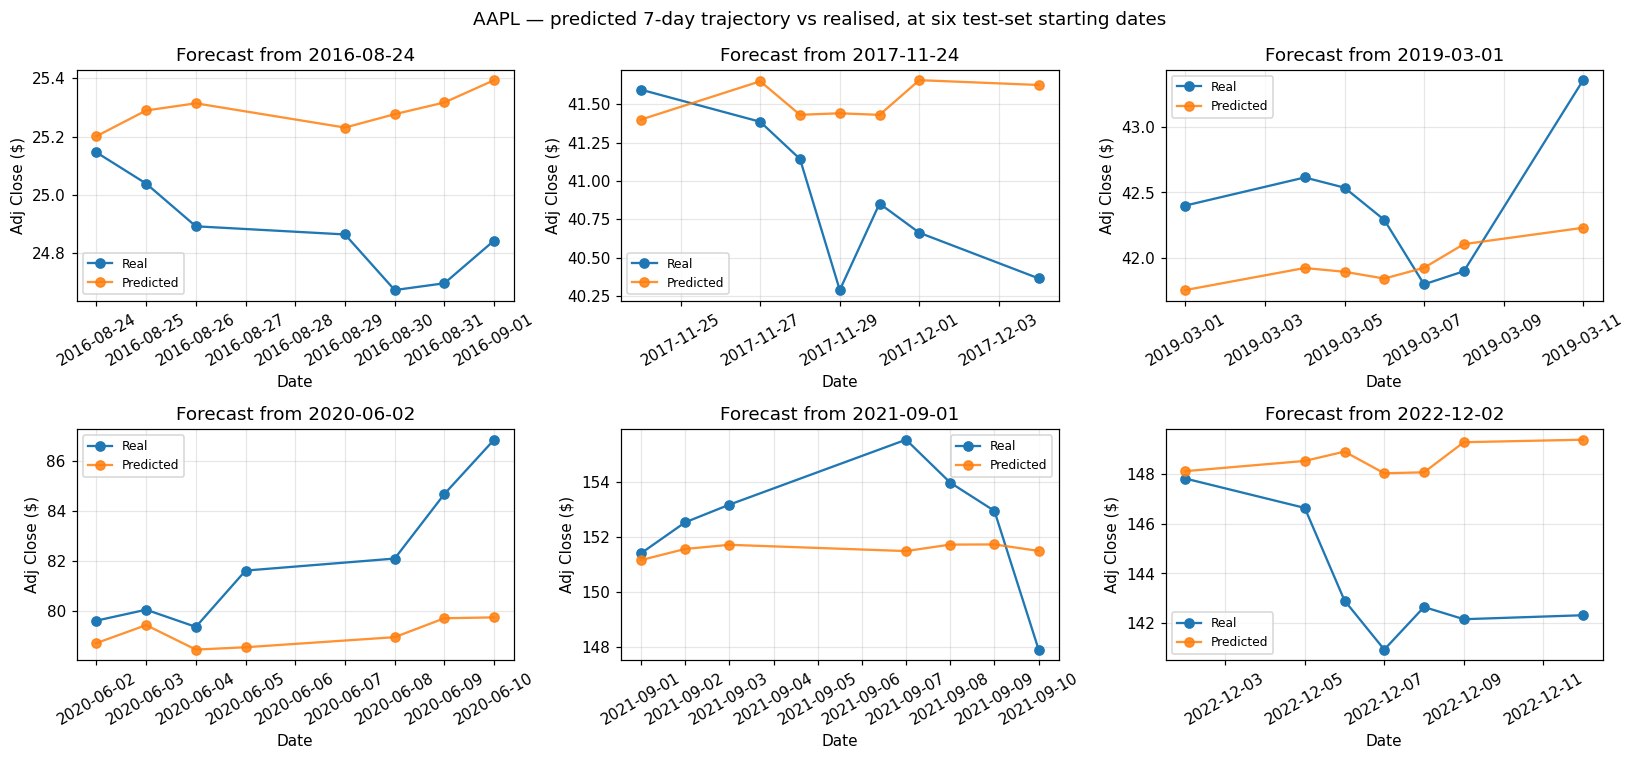

In [25]:
# AAPL k=7 forecast trajectories at six evenly-spaced starting dates from the test set.
window_size = 30
k = 7
r = results_kday[('AAPL', k)]
y_real, y_pred, _ = evaluate_test_multistep(r['model'], r['test'])     # (N, 7) each

# Recover the calendar date of the *first* predicted day for each test window.
test_start_idx = r['train'].X.shape[0] + r['val'].X.shape[0]
first_label_offset = window_size
N = y_pred.shape[0]
sample_indices = np.linspace(0, N - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), dpi=110, sharey=False)
for ax, idx in zip(axes.ravel(), sample_indices):
    base_idx = test_start_idx + first_label_offset + idx
    dates = feat_aapl['Date'].iloc[base_idx : base_idx + k].reset_index(drop=True)

    ax.plot(dates, y_real[idx], marker='o', label='Real',      color='tab:blue')
    ax.plot(dates, y_pred[idx], marker='o', label='Predicted', color='tab:orange', alpha=0.85)
    ax.set_title(f"Forecast from {dates.iloc[0].date()}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Adj Close ($)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('AAPL — predicted 7-day trajectory vs realised, at six test-set starting dates')
plt.tight_layout()
plt.show()
